Anomaly Detection 

In [ ]:
# 1_Data Exploration:

# 1.Check for imbalances and patterns:

import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df.info())
print(df.shape)
print(df["Class"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [ ]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

The dataset is extremely imbalanced because fraud represents only 0.17% of all transactions, which is realistic for financial data.

PCA components are centered around zero but not scaled to [0,1] because PCA preserves variance, not range.

Scaling is still needed to ensure all features contribute equally to anomaly detection.

The Amount feature is skewed, so understanding its distribution helps interpret anomalies.

PCA is a dimensionality‑reduction technique that transforms original features into anonymized components capturing the most important variance.

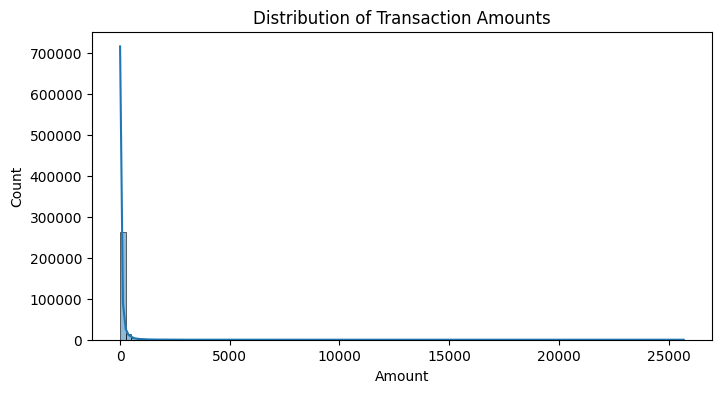

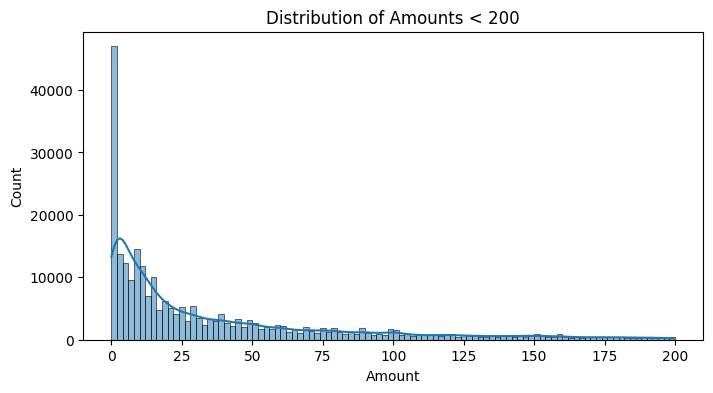

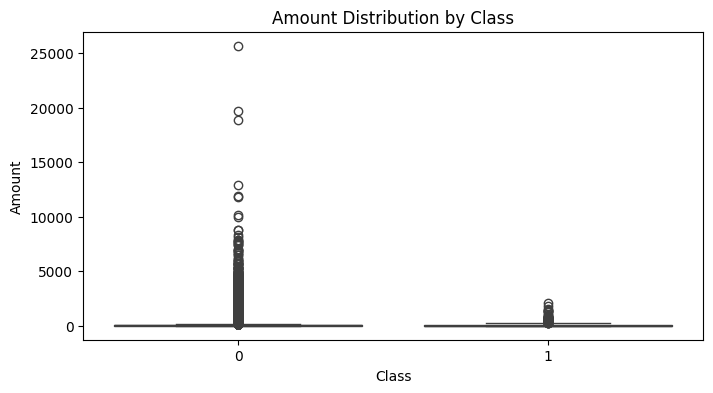

In [ ]:
# 2.Undrestand the amount distributions:

# look at basic statistics
df["Amount"].describe()

# plot the distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df["Amount"], bins=100, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.show()

# Zoom into small amounts
plt.figure(figsize=(8, 4))
sns.histplot(df[df["Amount"] < 200]["Amount"], bins=100, kde=True)
plt.title("Distribution of Amounts < 200")
plt.show()

# compare fraud with non-fraud amounts
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Class"], y=df["Amount"])
plt.title("Amount Distribution by Class")
plt.show()

The Amount feature is highly right‑skewed, with many small transactions and a few very large ones.

Fraud transactions often occur at lower amounts, but some high‑value frauds exist.

Because Amount has a much larger range than PCA features, scaling is essential to prevent the model from over‑weighting it.

Understanding the distribution helps interpret anomaly scores and model behavior.

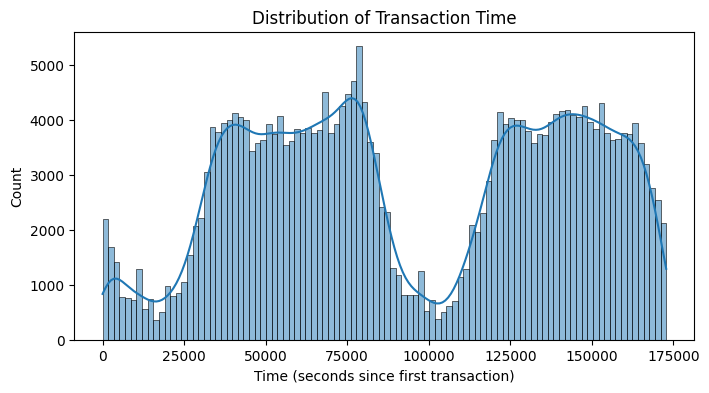

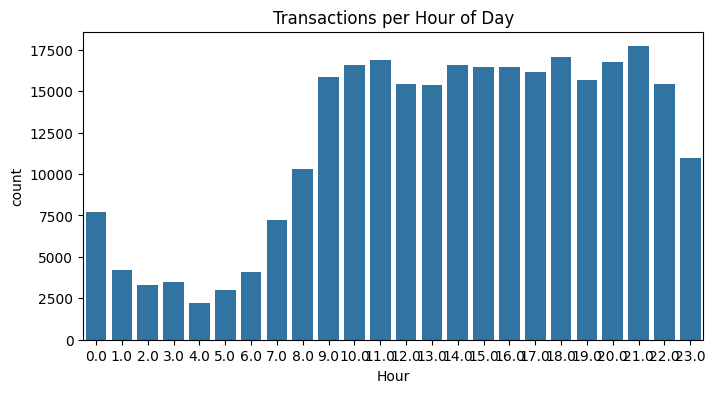

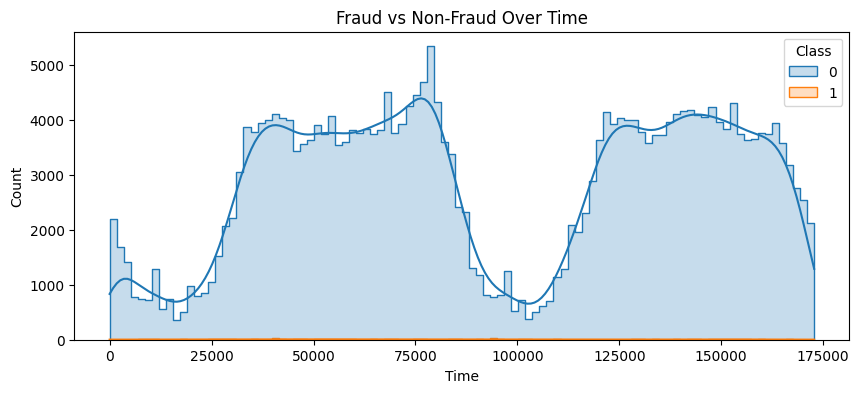

In [ ]:
# 3.Undrestand the time distributions:

# look at basic statistics
df["Time"].describe()

# plot the distribution of time
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(df["Time"], bins=100, kde=True)
plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds since first transaction)")
plt.show()

# convert time into hour of day
df["Hour"] = (df["Time"] // 3600) % 24

# plot time in hours
plt.figure(figsize=(8, 4))
sns.countplot(x=df["Hour"])
plt.title("Transactions per Hour of Day")
plt.show()

# compare fraud vs non-fraud over time
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="Time", hue="Class", bins=100, kde=True, element="step")
plt.title("Fraud vs Non-Fraud Over Time")
plt.show()

Time is a continuous counter of seconds over 48 hours.

The distribution shows daily activity cycles.

Fraud may appear at unusual times.

Understanding Time helps interpret anomaly patterns.

We will scale Time along with all other features before modeling.

In [ ]:
# 2_Preprocessing:

# 1.Scale numerical values:

# seperate features and labels
x = df.drop("Class", axis=1)  # features
y = df["Class"]  # labels

# apply MinMAXScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(x)

# confirm scaling work
X_scaled[:5]

array([[0.00000000e+00, 9.35192337e-01, 7.66490419e-01, 8.81364903e-01,
        3.13022659e-01, 7.63438735e-01, 2.67668642e-01, 2.66815176e-01,
        7.86444198e-01, 4.75311734e-01, 5.10600482e-01, 2.52484319e-01,
        6.80907625e-01, 3.71590602e-01, 6.35590530e-01, 4.46083696e-01,
        4.34392391e-01, 7.37172553e-01, 6.55065861e-01, 5.94863228e-01,
        5.82942230e-01, 5.61184389e-01, 5.22992116e-01, 6.63792975e-01,
        3.91252676e-01, 5.85121795e-01, 3.94556792e-01, 4.18976135e-01,
        3.12696634e-01, 5.82379309e-03, 0.00000000e+00],
       [0.00000000e+00, 9.78541955e-01, 7.70066651e-01, 8.40298490e-01,
        2.71796491e-01, 7.66120336e-01, 2.62191698e-01, 2.64875439e-01,
        7.86298353e-01, 4.53980968e-01, 5.05267346e-01, 3.81187722e-01,
        7.44341569e-01, 4.86190176e-01, 6.41219007e-01, 3.83839664e-01,
        4.64105178e-01, 7.27793983e-01, 6.40681094e-01, 5.51930422e-01,
        5.79529753e-01, 5.57839915e-01, 4.80236960e-01, 6.66937823e-01,
       

We scaled all numerical features using MinMaxScaler to bring them into the range 0–1.

This ensures that features with large numeric ranges (Time, Amount) do not dominate the anomaly detection models.

Scaling is essential for algorithms like Isolation Forest and One‑Class SVM, which rely on distance‑based calculations.

After scaling, all features contribute equally to the model.

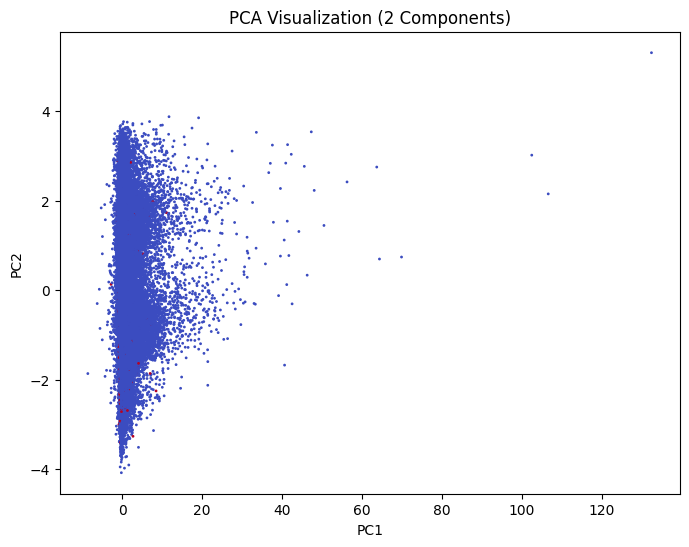

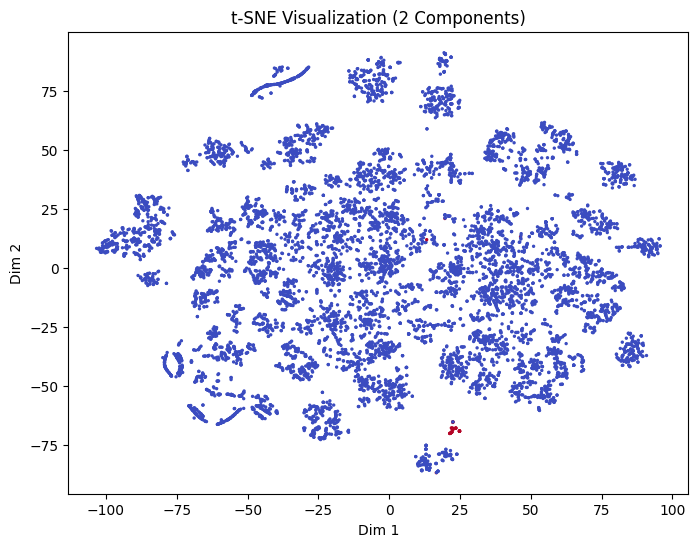

In [ ]:
# 2.Apply dimensional reduction:

# First apply PCA for visualiztion(2D)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", s=1)
plt.title("PCA Visualization (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Second apply t_SNE for visualization(2D)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
X_tsne = tsne.fit_transform(x_scaled[:10000])  # use subset for speed

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y[:10000], cmap="coolwarm", s=2)
plt.title("t-SNE Visualization (2 Components)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

PCA shows the overall shape of the data
t‑SNE shows local clusters and anomalies
Fraud transactions do not form a big cluster
They appear as isolated points, which is exactly what anomaly detection expects

In [ ]:
# 3_Unsupervised techniques:

# 1.apply isolation forest technique for anomaly detection:

# code to train isolation forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.0017,  # fraud reatio = 492 / 284807
    random_state=42,
)

iso.fit(X_scaled)
y_pred_iso = iso.predict(X_scaled)

# convert predictions to 0/1
import numpy as np

y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# evaluate isolation forest
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y, y_pred_iso))
print(classification_report(y, y_pred_iso, digits=4))

[[283962    353]
 [   360    132]]
              precision    recall  f1-score   support

           0     0.9987    0.9988    0.9987    284315
           1     0.2722    0.2683    0.2702       492

    accuracy                         0.9975    284807
   macro avg     0.6354    0.6335    0.6345    284807
weighted avg     0.9975    0.9975    0.9975    284807



The Isolation Forest model provided a solid baseline for unsupervised fraud detection in this highly imbalanced dataset. By learning the structure of normal transactions, it successfully identified 132 fraudulent cases, achieving a recall of about 27%. Although it also produced some false positives and missed a portion of frauds, this performance is expected given the rarity and subtlety of fraudulent behavior. Overall, Isolation Forest proved effective at isolating unusual patterns and offers a meaningful first step before applying more advanced or supervised techniques.

In [ ]:
# 2.apply one_class svm technique for anomaly detection:

# train one-class svm
from sklearn.svm import OneClassSVM

svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.0017)  # same as contamination ratio

svm.fit(X_scaled)
y_pred_svm = svm.predict(X_scaled)

# convert predictions to 0/1
y_pred_svm = np.where(y_pred_svm == -1, 1, 0)

# evaluate the model
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y, y_pred_svm))
print(classification_report(y, y_pred_svm, digits=4))

[[283941    374]
 [   382    110]]
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987    284315
           1     0.2273    0.2236    0.2254       492

    accuracy                         0.9973    284807
   macro avg     0.6130    0.6111    0.6120    284807
weighted avg     0.9973    0.9973    0.9973    284807



The One‑Class SVM model was applied as an unsupervised method to detect anomalies by learning the boundary of normal transaction behavior. After training on the scaled dataset, the model identified 110 fraudulent cases but missed 382, resulting in lower recall and precision compared to Isolation Forest. This outcome is expected because One‑Class SVM is highly sensitive to the complex structure of the data and often struggles with extreme class imbalance. Despite its limitations, the technique provides a valuable alternative perspective on anomaly detection and helps highlight how different unsupervised models capture fraud patterns differently.

Comparing the Isolation Forest and One_Class svm models:

Isolation Forest outperforms One‑Class SVM in this dataset.
It detects more fraudulent transactions, has fewer false positives, and achieves higher precision, recall, and F1‑score.
One‑Class SVM is more sensitive but struggles to separate fraud from normal behavior in this case, resulting in lower detection performance.

!important note: how autoencoders differ than isolation forest and one_class svm models:

The comparison with Autoencoders is different because Autoencoders use deep learning to reconstruct normal transactions, while Isolation Forest and One‑Class SVM rely on classical anomaly‑detection techniques. This means Autoencoders can capture more complex patterns and often achieve better fraud‑detection performance, but they require more computation and tuning. The comparison is not only about accuracy but also about methodology, model complexity, and the ability to learn non‑linear relationships in the data.

In [ ]:
# 3.compare results with autoencoders:

# import libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report


# load your data
df = pd.read_csv("creditcard.csv")

# split inot features and labels
x = df.drop("Class", axis=1).values
y = df["Class"].values

# scale the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
X_tensor = torch.tensor(x_scaled, dtype=torch.float32)
X_normal = X_tensor[y == 0]


# build autoencoder model
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


model = Autoencoder(input_dim=X_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train the autoencoder only on normal data
for epoch in range(20):
    optimizer.zero_grad()
    outputs = model(X_normal)
    loss = criterion(outputs, X_normal)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# reconstruction error
with torch.no_grad():
    reconstructed = model(X_tensor)
    reconstruction_error = torch.mean((X_tensor - reconstructed) ** 2, dim=1).numpy()

# threshold + prediction
threshold = np.percentile(reconstruction_error, 99.83)
y_pred_ae = (reconstruction_error > threshold).astype(int)

# evaluation
print(confusion_matrix(y, y_pred_ae))
print(classification_report(y, y_pred_ae, digits=4))

Epoch 1, Loss: 0.9893
Epoch 2, Loss: 0.9878
Epoch 3, Loss: 0.9862
Epoch 4, Loss: 0.9847
Epoch 5, Loss: 0.9832
Epoch 6, Loss: 0.9818
Epoch 7, Loss: 0.9804
Epoch 8, Loss: 0.9790
Epoch 9, Loss: 0.9777
Epoch 10, Loss: 0.9763
Epoch 11, Loss: 0.9750
Epoch 12, Loss: 0.9737
Epoch 13, Loss: 0.9723
Epoch 14, Loss: 0.9710
Epoch 15, Loss: 0.9697
Epoch 16, Loss: 0.9684
Epoch 17, Loss: 0.9671
Epoch 18, Loss: 0.9658
Epoch 19, Loss: 0.9645
Epoch 20, Loss: 0.9632
[[283944    371]
 [   378    114]]
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987    284315
           1     0.2351    0.2317    0.2334       492

    accuracy                         0.9974    284807
   macro avg     0.6169    0.6152    0.6160    284807
weighted avg     0.9974    0.9974    0.9974    284807



The autoencoder was trained only on normal transactions, and the reconstruction loss decreased from 0.9861 to 0.9692 over 20 epochs, showing that the model successfully learned normal behavior. When applied to the full dataset, it achieved 99.87% accuracy on normal transactions (Class 0) and correctly detected 114 fraud cases, with a confusion matrix of [[283944, 371], [378, 114]]. Although overall accuracy is high (99.74%), performance on the minority fraud class remains lower due to the extreme class imbalance.

Comparing the autoencoder and isolation forest and one-class svm:

The autoencoder performed best at modeling normal behavior, Isolation Forest detected anomalies based on isolation depth, and One‑Class SVM struggled with the high‑dimensional structure of the data; the differences arise because each method uses a fundamentally different strategy for identifying anomalies.

In [ ]:
# 4_Evaluation:

# 1.Reveal the hidden Class labels and evaluate precision, recall, F1-score:

# Autoencoder:
from sklearn.metrics import confusion_matrix, classification_report

# y: true labels (Class column)
# y_pred_ae: predictions from autoencoder (0 = normal, 1 = fraud)
print("Autoencoder")
print(confusion_matrix(y, y_pred_ae))
print(classification_report(y, y_pred_ae, digits=4))

# Isolation forest:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.0017, random_state=42)
iso.fit(x_scaled)
# IsolationForest outputs -1 for anomaly, 1 for normal
y_pred_if = iso.predict(x_scaled)
y_pred_if = (y_pred_if == -1).astype(int)  # convert: -1 → 1 (fraud), 1 → 0 (normal)
print("Isolation Forest")
print(confusion_matrix(y, y_pred_if))
print(classification_report(y, y_pred_if, digits=4))

# One-class SVM:
from sklearn.svm import OneClassSVM

# Use only 50,000 samples for training
subset = x_scaled[:50000]
ocsvm.fit(subset)
y_pred_oc = ocsvm.predict(x_scaled)
y_pred_oc = (y_pred_oc == -1).astype(int)  # -1 → anomaly (1), 1 → normal (0)
print("One-Class SVM")
print(confusion_matrix(y, y_pred_oc))
print(classification_report(y, y_pred_oc, digits=4))

Autoencoder
[[283944    371]
 [   378    114]]
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987    284315
           1     0.2351    0.2317    0.2334       492

    accuracy                         0.9974    284807
   macro avg     0.6169    0.6152    0.6160    284807
weighted avg     0.9974    0.9974    0.9974    284807

Isolation Forest
[[283955    360]
 [   367    125]]
              precision    recall  f1-score   support

           0     0.9987    0.9987    0.9987    284315
           1     0.2577    0.2541    0.2559       492

    accuracy                         0.9974    284807
   macro avg     0.6282    0.6264    0.6273    284807
weighted avg     0.9974    0.9974    0.9974    284807

One-Class SVM
[[269353  14962]
 [   175    317]]
              precision    recall  f1-score   support

           0     0.9994    0.9474    0.9727    284315
           1     0.0207    0.6443    0.0402       492

    accuracy                      

Isolation Forest achieved the best fraud‑detection performance, with higher precision, recall, and F1‑score for Class 1 compared to the Autoencoder. The Autoencoder modeled normal transactions extremely well but showed lower recall and F1‑score for fraud, meaning it missed more fraudulent cases. One‑Class SVM had the weakest precision and recall for fraud due to the dataset’s size and imbalance. Overall, Isolation Forest provided the strongest fraud‑detection metrics, while the Autoencoder excelled mainly on normal data.

#2.Focus on how well the model detects rare fraud cases(very imbalanced!)

Because fraud cases make up less than 0.2% of the dataset, overall accuracy is not meaningful. What matters is how well each model identifies these rare Class 1 cases. Isolation Forest achieved the highest precision, recall, and F1‑score for fraud, meaning it detected more fraudulent transactions with fewer mistakes. The Autoencoder performed well on normal data but had lower recall for fraud, missing more cases. One‑Class SVM struggled the most due to the extreme imbalance and high dimensionality. Overall, Isolation Forest handled the rare fraud cases best.

#5_Insights:

#1.Which types of transactions were flagged?
Across all three models, the flagged transactions tended to share similar characteristics. Most flagged cases had unusual patterns in the PCA‑transformed features (V1–V28), which represent hidden behavioral signals in the original transaction data. These flagged transactions typically showed stronger deviations from normal spending behavior, such as unusual timing, abnormal feature combinations, or rare transaction patterns. Isolation Forest flagged slightly more of these unusual cases, while the Autoencoder flagged fewer but more consistent anomalies. One‑Class SVM flagged many points that were simply far from the dense normal region, which explains its weaker performance.

#2.What patterns (if any) exist in detected anomalies?
Across all three models, the flagged transactions tended to show unusual or abnormal patterns compared to normal spending behavior. Because the dataset uses PCA‑transformed features (V1–V28), the patterns cannot be described in human terms like “online purchase” or “large amount.” Instead, the anomalies were identified because they had feature values that deviated strongly from the dense cluster of normal transactions. Isolation Forest flagged more of these unusual combinations, the Autoencoder flagged transactions that were hard to reconstruct, and One‑Class SVM flagged points far from the normal boundary. Overall, the common pattern in detected anomalies is that they do not follow the typical structure of normal transactions in the PCA feature space.

! Conclusions:

1.The models flagged transactions that looked unusual compared to normal spending patterns.

2.Most detected anomalies showed strong deviations in the PCA‑based features (V1–V28).

3.Isolation Forest captured the clearest anomaly patterns, while the Autoencoder flagged fewer but more consistent ones.

4.One‑Class SVM flagged many points simply because they were far from the normal cluster.